# Daily Challenge — Global Power Plant Database

Analyse complète avec NumPy, Pandas et Matplotlib.

## Task 1 — Data Import and Cleaning

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('global_power_plant_database.csv', low_memory=False)
print(f'Shape : {{df.shape[0]}} lignes x {{df.shape[1]}} colonnes')
df.head(3)


Shape : {df.shape[0]} lignes x {df.shape[1]} colonnes


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.119,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.795,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.792,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE


In [5]:
# Valeurs manquantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Colonnes avec valeurs manquantes :')
print(missing.to_string())


Colonnes avec valeurs manquantes :
other_fuel3                      34844
other_fuel2                      34660
other_fuel1                      32992
generation_gwh_2013              28519
generation_gwh_2014              27710
generation_gwh_2015              26733
generation_gwh_2016              25792
generation_gwh_2017              25436
generation_gwh_2018              25299
generation_gwh_2019              25277
generation_data_source           23536
year_of_capacity_data            20049
estimated_generation_gwh_2013    18816
wepp_id                          18702
estimated_generation_gwh_2014    18433
estimated_generation_gwh_2015    17886
commissioning_year               17489
estimated_generation_gwh_2016    17366
owner                            14068
estimated_generation_gwh_2017     1798
geolocation_source                 419
url                                 18
source                              15


In [3]:
# Colonnes inutiles (>80% manquantes)
threshold = 0.80 * len(df)
cols_to_drop = [c for c in df.columns if df[c].isnull().sum() > threshold]
df.drop(columns=cols_to_drop, inplace=True)
print('Colonnes supprimees :', cols_to_drop)

# Remplir capacity_mw manquant par la médiane
df['capacity_mw'].fillna(df['capacity_mw'].median(), inplace=True)

# Convertir commissioning_year en entier (NumPy)
df['commissioning_year'] = pd.to_numeric(df['commissioning_year'], errors='coerce')
year_arr = df['commissioning_year'].dropna().values.astype(np.int32)
print(f'\nannées valides : {{len(year_arr)}} | min={{year_arr.min()}} max={{year_arr.max()}}')

# capacity_mw en array NumPy float32
cap_arr = df['capacity_mw'].values.astype(np.float32)
print(f'capacity_mw -> NumPy float32, shape={{cap_arr.shape}}')

print(f'\nShape apres nettoyage : {{df.shape}}')


Colonnes supprimees : ['other_fuel1', 'other_fuel2', 'other_fuel3', 'generation_gwh_2013']

années valides : {len(year_arr)} | min={year_arr.min()} max={year_arr.max()}
capacity_mw -> NumPy float32, shape={cap_arr.shape}

Shape apres nettoyage : {df.shape}


## Task 2 — Exploratory Data Analysis

In [4]:
# Statistiques descriptives des colonnes numériques
num_cols = ['capacity_mw','latitude','longitude']
print(df[num_cols].describe().round(2).to_string())


       capacity_mw  latitude  longitude
count     34936.00  34936.00   34936.00
mean        163.36     32.82      -6.97
std         489.64     22.64      78.41
min           1.00    -77.85    -179.98
25%           4.90     29.26     -77.64
50%          16.74     39.73      -2.13
75%          75.34     46.26      49.50
max       22500.00     71.29     179.39


In [5]:
# Distribution par pays (top 10)
top_countries = df['country_long'].value_counts().head(10)
print('Top 10 pays :')
print(top_countries.to_string())


Top 10 pays :
country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
India                       1589
Germany                     1309
Canada                      1159
Spain                        829
Russia                       545


In [6]:
# Distribution par type de combustible
fuel_counts = df['primary_fuel'].value_counts()
print('Repartition par fuel :')
print(fuel_counts.to_string())


Repartition par fuel :
primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10


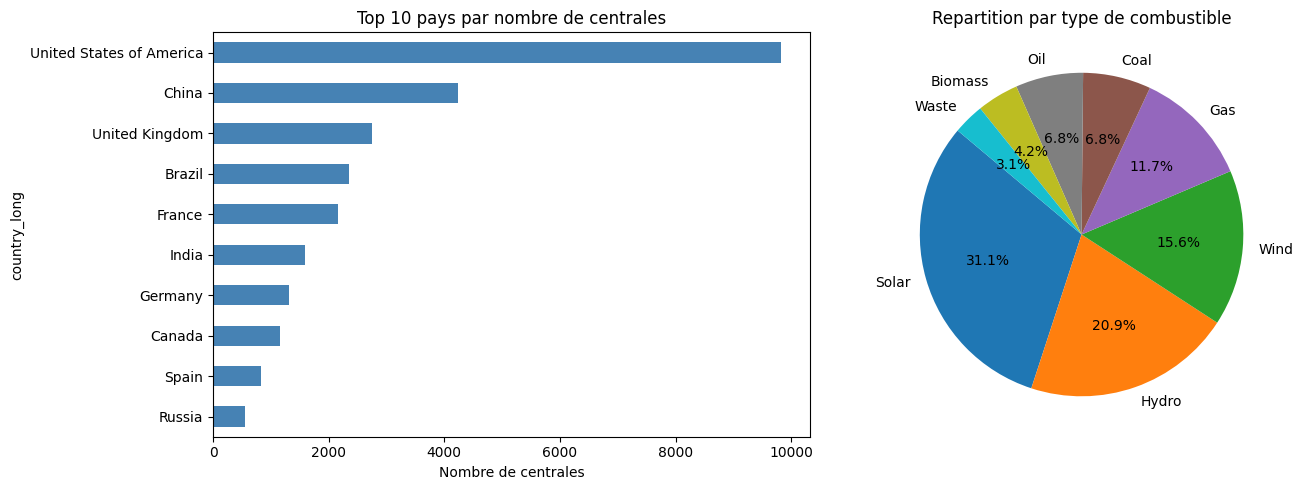

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot pays
top_countries.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 pays par nombre de centrales')
axes[0].set_xlabel('Nombre de centrales')
axes[0].invert_yaxis()

# Pie fuel
fuel_counts.head(8).plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                          startangle=140, colormap='tab10')
axes[1].set_title('Repartition par type de combustible')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


## Task 3 — Statistical Analysis

In [8]:
# Statistiques NumPy de la capacité par fuel
top_fuels = ['Solar','Hydro','Wind','Gas','Coal','Nuclear']
print(f'{{"Fuel":<12}} {{"Moyenne":>10}} {{"Mediane":>10}} {{"Std":>10}} {{"Max":>10}}')
print('-'*46)
for fuel in top_fuels:
    arr = df[df['primary_fuel'] == fuel]['capacity_mw'].values
    print(f'{{fuel:<12}} {{np.mean(arr):>10.1f}} {{np.median(arr):>10.1f}} '
          f'{{np.std(arr):>10.1f}} {{np.max(arr):>10.1f}}')


{"Fuel":<12} {"Moyenne":>10} {"Mediane":>10} {"Std":>10} {"Max":>10}
----------------------------------------------
{fuel:<12} {np.mean(arr):>10.1f} {np.median(arr):>10.1f} {np.std(arr):>10.1f} {np.max(arr):>10.1f}
{fuel:<12} {np.mean(arr):>10.1f} {np.median(arr):>10.1f} {np.std(arr):>10.1f} {np.max(arr):>10.1f}
{fuel:<12} {np.mean(arr):>10.1f} {np.median(arr):>10.1f} {np.std(arr):>10.1f} {np.max(arr):>10.1f}
{fuel:<12} {np.mean(arr):>10.1f} {np.median(arr):>10.1f} {np.std(arr):>10.1f} {np.max(arr):>10.1f}
{fuel:<12} {np.mean(arr):>10.1f} {np.median(arr):>10.1f} {np.std(arr):>10.1f} {np.max(arr):>10.1f}
{fuel:<12} {np.mean(arr):>10.1f} {np.median(arr):>10.1f} {np.std(arr):>10.1f} {np.max(arr):>10.1f}


In [9]:
# Test t de Student : Solar vs Wind (capacité moyenne différente ?)
# H0 : moyennes identiques | H1 : moyennes différentes
from scipy import stats

pairs = [('Solar','Wind'), ('Coal','Gas'), ('Hydro','Nuclear')]
print(f'{{"Comparaison":<25}} {{"t-score":>10}} {{"p-value":>12}} {{"Decision":>20}}')
print('-'*70)
for f1, f2 in pairs:
    a1 = df[df['primary_fuel']==f1]['capacity_mw'].values
    a2 = df[df['primary_fuel']==f2]['capacity_mw'].values
    t, p = stats.ttest_ind(a1, a2, equal_var=False)
    decision = 'Rejet H0 (diff.)' if p < 0.05 else 'Non rejet H0'
    print(f'{{f1}} vs {{f2:<15}} {{t:>10.3f}} {{p:>12.6f}} {{decision:>20}}')


{"Comparaison":<25} {"t-score":>10} {"p-value":>12} {"Decision":>20}
----------------------------------------------------------------------
{f1} vs {f2:<15} {t:>10.3f} {p:>12.6f} {decision:>20}
{f1} vs {f2:<15} {t:>10.3f} {p:>12.6f} {decision:>20}
{f1} vs {f2:<15} {t:>10.3f} {p:>12.6f} {decision:>20}


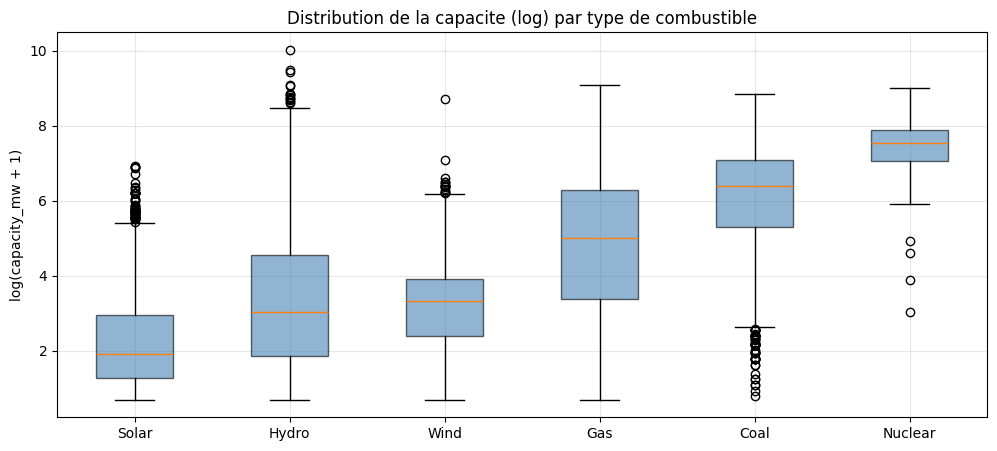

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
data_box = [np.log1p(df[df['primary_fuel']==f]['capacity_mw'].values) for f in top_fuels]
ax.boxplot(data_box, labels=top_fuels, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_title('Distribution de la capacite (log) par type de combustible')
ax.set_ylabel('log(capacity_mw + 1)')
ax.grid(True, alpha=0.3)
plt.show()


## Task 4 — Time Series Analysis

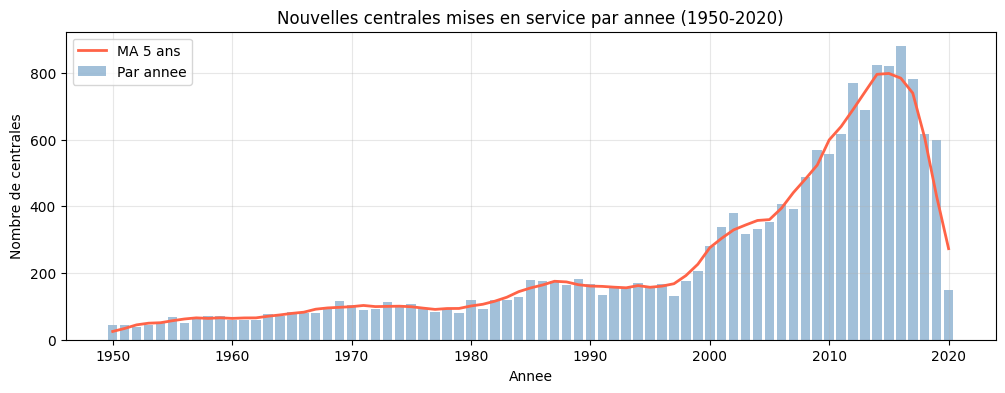

In [11]:
# Centrales par année de mise en service
ts = df.dropna(subset=['commissioning_year']).copy()
ts['year'] = ts['commissioning_year'].astype(int)
ts = ts[(ts['year'] >= 1950) & (ts['year'] <= 2020)]

plants_per_year = ts.groupby('year')['name'].count()

# Moyenne mobile 5 ans avec NumPy
counts = plants_per_year.values.astype(np.float64)
ma5 = np.convolve(counts, np.ones(5)/5, mode='same')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(plants_per_year.index, counts, color='steelblue', alpha=0.5, label='Par annee')
ax.plot(plants_per_year.index, ma5, color='tomato', linewidth=2, label='MA 5 ans')
ax.set_title('Nouvelles centrales mises en service par annee (1950-2020)')
ax.set_xlabel('Annee')
ax.set_ylabel('Nombre de centrales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


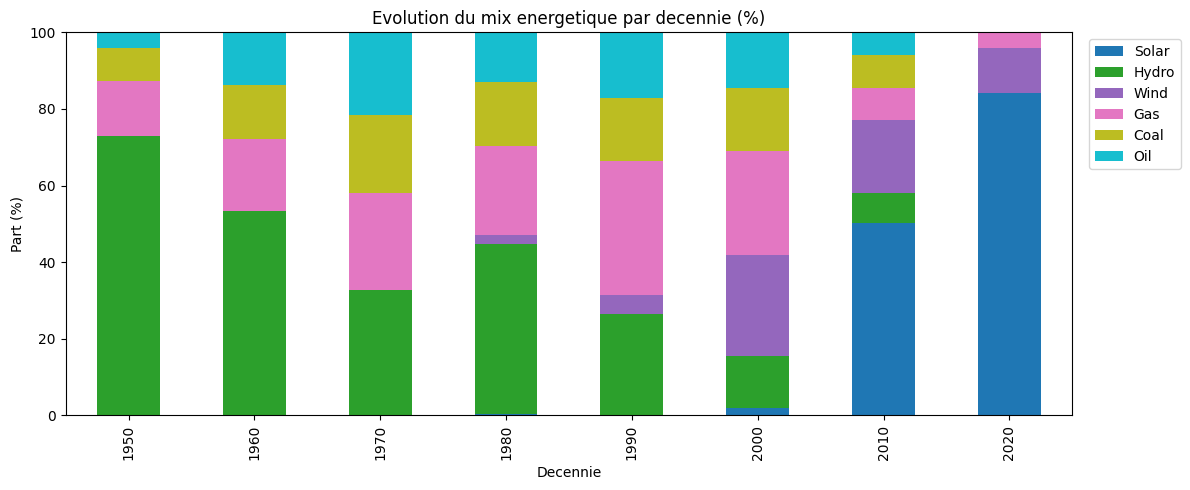

In [12]:
# Evolution du mix energetique par décennie
ts['decade'] = (ts['year'] // 10) * 10
mix = ts.groupby(['decade','primary_fuel'])['name'].count().unstack(fill_value=0)

# Garder les 6 fuels principaux
top6 = df['primary_fuel'].value_counts().head(6).index.tolist()
mix = mix[[c for c in top6 if c in mix.columns]]

# Normaliser en pourcentage (NumPy)
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100

mix_pct.plot(kind='bar', stacked=True, figsize=(12,5), colormap='tab10')
plt.title('Evolution du mix energetique par decennie (%)')
plt.xlabel('Decennie')
plt.ylabel('Part (%)')
plt.legend(bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.show()


## Task 5 — Advanced Visualization

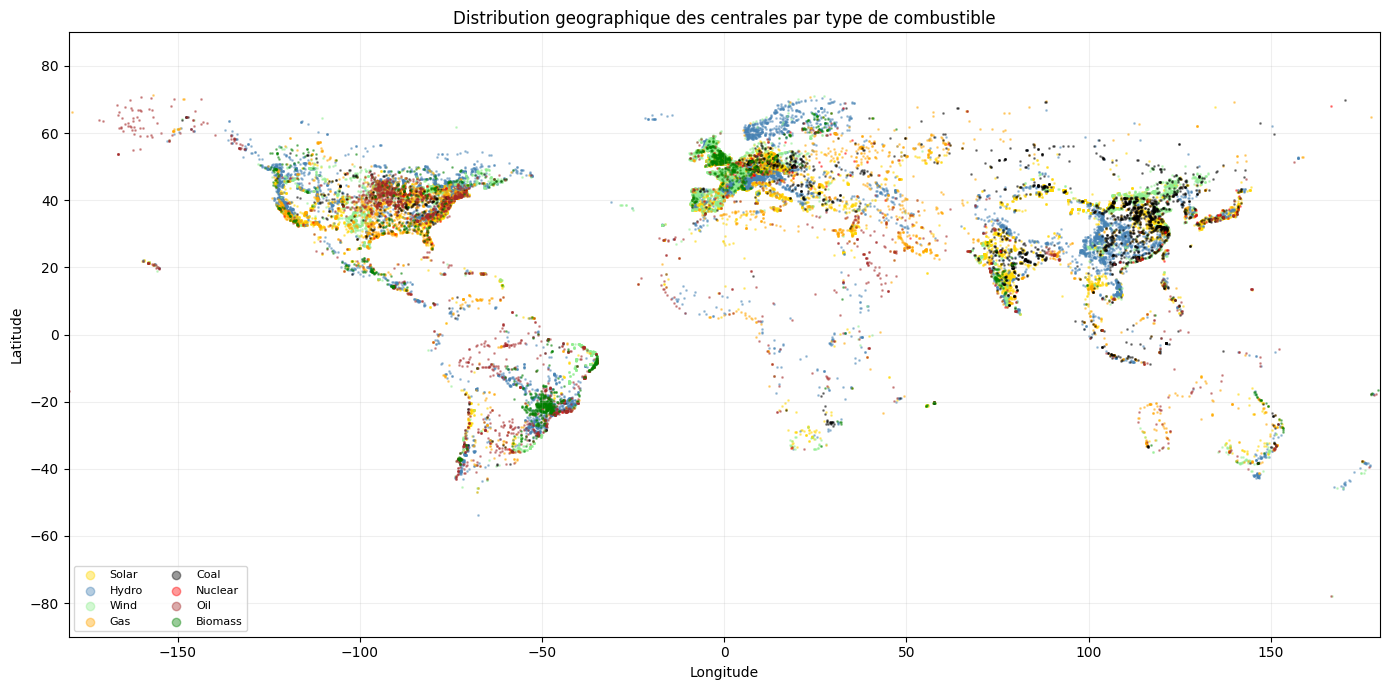

In [13]:
# Distribution géographique des centrales
fuel_colors = {'Solar':'gold','Hydro':'steelblue','Wind':'lightgreen',
               'Gas':'orange','Coal':'black','Nuclear':'red',
               'Oil':'brown','Biomass':'green'}

fig, ax = plt.subplots(figsize=(14, 7))
for fuel, color in fuel_colors.items():
    sub = df[df['primary_fuel'] == fuel]
    ax.scatter(sub['longitude'], sub['latitude'],
               c=color, s=1, alpha=0.4, label=fuel)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_title('Distribution geographique des centrales par type de combustible')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=6, loc='lower left', ncol=2, fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


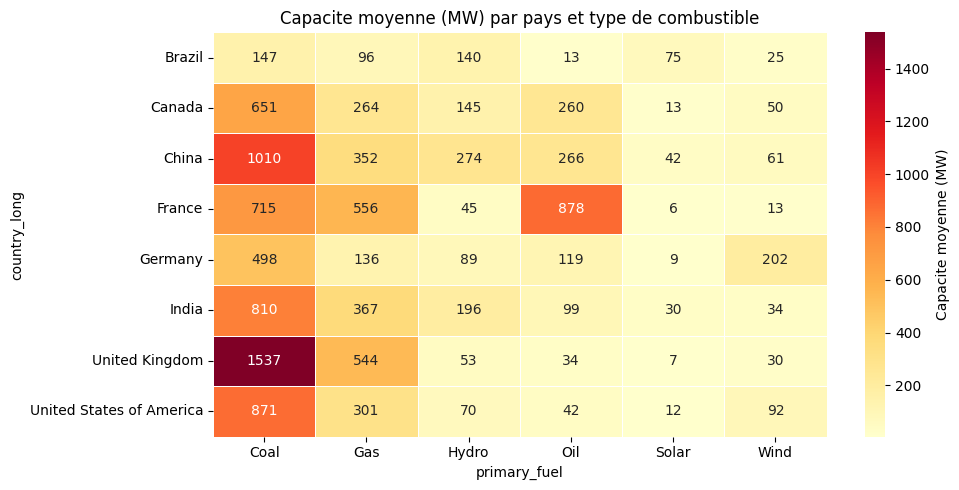

In [14]:
# Heatmap : capacité moyenne par pays et fuel (top 8 pays, top 6 fuels)
top8_c = df['country_long'].value_counts().head(8).index
top6_f = df['primary_fuel'].value_counts().head(6).index

pivot = df[df['country_long'].isin(top8_c) & df['primary_fuel'].isin(top6_f)]\
          .groupby(['country_long','primary_fuel'])['capacity_mw'].mean()\
          .unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label':'Capacite moyenne (MW)'})
ax.set_title('Capacite moyenne (MW) par pays et type de combustible')
plt.tight_layout()
plt.show()


## Task 6 — Matrix Operations

In [15]:
# Matrice de features numériques : capacity, latitude, longitude
features = df[['capacity_mw','latitude','longitude']].dropna()
X = features.values.astype(np.float64)

# Normalisation (centrage-réduction) avec NumPy
X_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# Matrice de covariance
cov = np.cov(X_norm.T)
print('Matrice de covariance :')
print(cov.round(4))

# Valeurs propres et vecteurs propres (PCA manuelle)
eigenvalues, eigenvectors = np.linalg.eig(cov)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

variance_explained = eigenvalues / eigenvalues.sum() * 100
print('\nVariance expliquee par composante :')
for i, v in enumerate(variance_explained):
    print(f'  PC{i+1} : {v:.1f}%')


Matrice de covariance :
[[ 1.     -0.0132  0.1515]
 [-0.0132  1.     -0.0684]
 [ 0.1515 -0.0684  1.    ]]

Variance expliquee par composante :
  PC1 : 39.0%
  PC2 : 33.0%
  PC3 : 27.9%


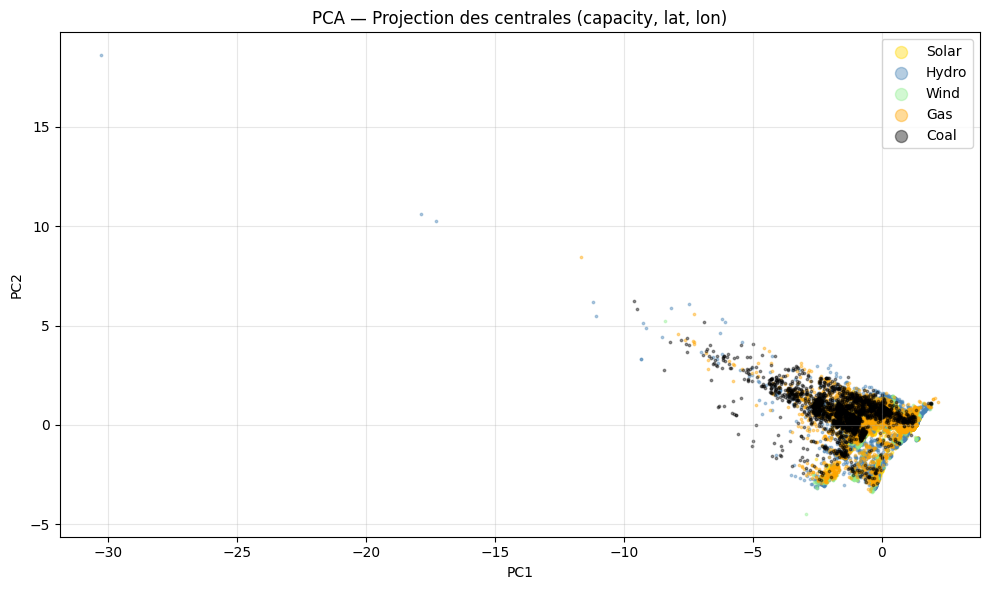

In [16]:
# Projection sur les 2 premières composantes principales
X_pca = X_norm @ eigenvectors[:, :2]

# Colorier par fuel
fuel_labels = df.loc[features.index, 'primary_fuel']
top5 = df['primary_fuel'].value_counts().head(5).index

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['gold','steelblue','lightgreen','orange','black']
for fuel, color in zip(top5, colors):
    mask = fuel_labels == fuel
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, s=3, alpha=0.4, label=fuel)

ax.set_title('PCA — Projection des centrales (capacity, lat, lon)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(markerscale=5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Task 7 — Intégration NumPy / Pandas / Matplotlib

In [17]:
# Filtrage complexe avec NumPy : centrales 'grandes' (> 1 ecart-type au-dessus)
cap = df['capacity_mw'].values
seuil = np.mean(cap) + np.std(cap)
mask = cap > seuil

grandes = df[mask][['name','country_long','primary_fuel','capacity_mw']]
print(f'Centrales au-dessus du seuil ({seuil:.1f} MW) : {mask.sum()}')
print(grandes.sort_values('capacity_mw', ascending=False).head(10).to_string(index=False))


Centrales au-dessus du seuil (653.0 MW) : 2534
                                   name country_long primary_fuel  capacity_mw
                       Three Gorges Dam        China        Hydro      22500.0
                           Baihetan Dam        China        Hydro      13050.0
                                Xiluodu        China        Hydro      12600.0
                     Surgutskaya GRES-2       Russia          Gas       8865.0
                   Simon Bolivar (Guri)    Venezuela        Hydro       8851.0
                                Tucuruí       Brazil        Hydro       8535.0
                     Kashiwazaki Kariwa        Japan      Nuclear       8212.0
              Itaipu (Parte Brasileira)       Brazil        Hydro       7000.0
  Itaipu Binacional Dam (Paraguay part)     Paraguay        Hydro       7000.0
East Hope Metals Wucaiwan power station        China         Coal       7000.0


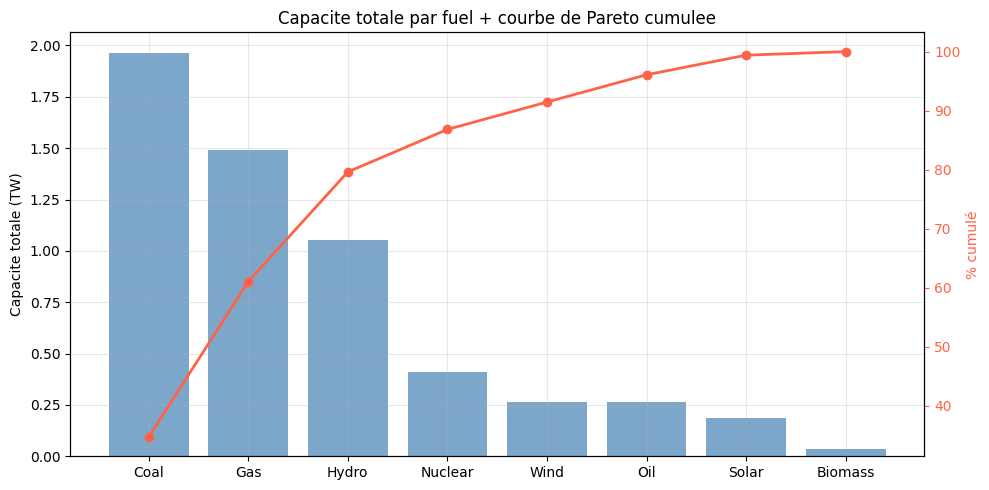

In [18]:
# Visualisation : capacité cumulée par fuel (NumPy cumsum)
fuel_cap = df.groupby('primary_fuel')['capacity_mw'].sum().sort_values(ascending=False).head(8)
cumsum   = np.cumsum(fuel_cap.values)
pct_cum  = cumsum / cumsum[-1] * 100

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(fuel_cap.index, fuel_cap.values / 1e6, color='steelblue', alpha=0.7)
ax2.plot(fuel_cap.index, pct_cum, color='tomato', marker='o', linewidth=2)

ax1.set_ylabel('Capacite totale (TW)')
ax2.set_ylabel('% cumulé', color='tomato')
ax2.tick_params(axis='y', colors='tomato')
ax1.set_title('Capacite totale par fuel + courbe de Pareto cumulee')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
